In [4]:
!pip -q install pandas numpy matplotlib seaborn scikit-learn xgboost scipy

In [5]:
# Importing Libraries
import io
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & Clustering
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

# Classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    silhouette_score,
    accuracy_score,
    classification_report,
    confusion_matrix
)

# XGBoost
from xgboost import XGBClassifier
     

In [7]:
# Loading Dataset
df = pd.read_csv('Country-data[2].csv')

print('Shape:', df.shape)
df.head()

Shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [8]:
# Added skewness and outlier audit alongside the original describe/info
print('Shape:', df.shape)
display(df.head())
display(df.info())
display(df.describe(include='all').T)

Shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
country,167,167,Afghanistan,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
child_mort,167.0,NaN,NaN,NaN,38.27006,40.328931,2.6,8.25,19.3,62.1,208.0
exports,167.0,NaN,NaN,NaN,41.108976,27.41201,0.109,23.8,35.0,51.35,200.0
health,167.0,NaN,NaN,NaN,6.815689,2.746837,1.81,4.92,6.32,8.6,17.9
imports,167.0,NaN,NaN,NaN,46.890215,24.209589,0.0659,30.2,43.3,58.75,174.0
income,167.0,NaN,NaN,NaN,17144.688623,19278.067698,609.0,3355.0,9960.0,22800.0,125000.0
inflation,167.0,NaN,NaN,NaN,7.781832,10.570704,-4.21,1.81,5.39,10.75,104.0
life_expec,167.0,NaN,NaN,NaN,70.555689,8.893172,32.1,65.3,73.1,76.8,82.8
total_fer,167.0,NaN,NaN,NaN,2.947964,1.513848,1.15,1.795,2.41,3.88,7.49
gdpp,167.0,NaN,NaN,NaN,12964.155689,18328.704809,231.0,1330.0,4660.0,14050.0,105000.0


In [9]:
#Skewness report -
# Values above 1 = right-skewed = (need log transform before scaling)

print('Skewness (|value| > 1 = needs log transform)')
skew = df.select_dtypes(include=np.number).skew().sort_values(ascending=False)
print(skew.round(3))
     


Skewness (|value| > 1 = needs log transform)
inflation     5.154
exports       2.446
income        2.231
gdpp          2.218
imports       1.905
child_mort    1.451
total_fer     0.967
health        0.706
life_expec   -0.971
dtype: float64


In [10]:
# Outliers (IQR method) -

print('\n--- Outlier ---')
numeric_cols = [c for c in df.columns if c != 'country']
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    out = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    if len(out) > 0:
        print(f'  {col}: {len(out)} outliers → {out["country"].tolist()}')


--- Outlier ---
  child_mort: 4 outliers → ['Central African Republic', 'Chad', 'Haiti', 'Sierra Leone']
  exports: 5 outliers → ['Ireland', 'Luxembourg', 'Malta', 'Seychelles', 'Singapore']
  health: 2 outliers → ['Micronesia, Fed. Sts.', 'United States']
  imports: 4 outliers → ['Luxembourg', 'Malta', 'Seychelles', 'Singapore']
  income: 8 outliers → ['Brunei', 'Kuwait', 'Luxembourg', 'Norway', 'Qatar', 'Singapore', 'Switzerland', 'United Arab Emirates']
  inflation: 5 outliers → ['Equatorial Guinea', 'Mongolia', 'Nigeria', 'Timor-Leste', 'Venezuela']
  life_expec: 3 outliers → ['Central African Republic', 'Haiti', 'Lesotho']
  total_fer: 1 outliers → ['Niger']
  gdpp: 25 outliers → ['Australia', 'Austria', 'Belgium', 'Brunei', 'Canada', 'Denmark', 'Finland', 'France', 'Germany', 'Iceland', 'Ireland', 'Italy', 'Japan', 'Kuwait', 'Luxembourg', 'Netherlands', 'New Zealand', 'Norway', 'Qatar', 'Singapore', 'Sweden', 'Switzerland', 'United Arab Emirates', 'United Kingdom', 'United State

In [11]:
# Flag negative inflations (critical — causes NaN in log) -

neg = df[df['inflation'] < 0]
if len(neg) > 0:
    print(f'\nWARNING: {len(neg)} countries have negative inflation:')
    print(neg[['country','inflation']].to_string(index=False))
     


       country  inflation
       Bahamas     -0.393
Czech Republic     -1.430
       Ireland     -3.220
         Japan     -1.900
        Latvia     -0.812
    Seychelles     -4.210
     Singapore     -0.046
      Slovenia     -0.987


In [12]:
print('Columns:', df.columns.tolist())

Columns: ['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


In [13]:
# Cleaning and Feature Engineering
df = df.copy()
df = df.drop_duplicates()

numeric_cols = [c for c in df.columns if c != 'country']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

print('Missing values after cleaning:\n', df.isna().sum())

Missing values after cleaning:
 country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


In [14]:
# Log-transform skewed columns (log1p = safe for 0 values)
# Inflation clipped first — has 8 negative values that cause NaN in log

LOG_COLS = ['child_mort', 'gdpp', 'income', 'exports', 'imports', 'inflation']
for col in LOG_COLS:
    df['log_' + col] = np.log1p(df[col].clip(lower=0))

print('\nLog columns created:', [c for c in df.columns if c.startswith('log_')])
print('NaN in log columns:', df.filter(like='log_').isna().sum().sum())
     


Log columns created: ['log_child_mort', 'log_gdpp', 'log_income', 'log_exports', 'log_imports', 'log_inflation']
NaN in log columns: 0


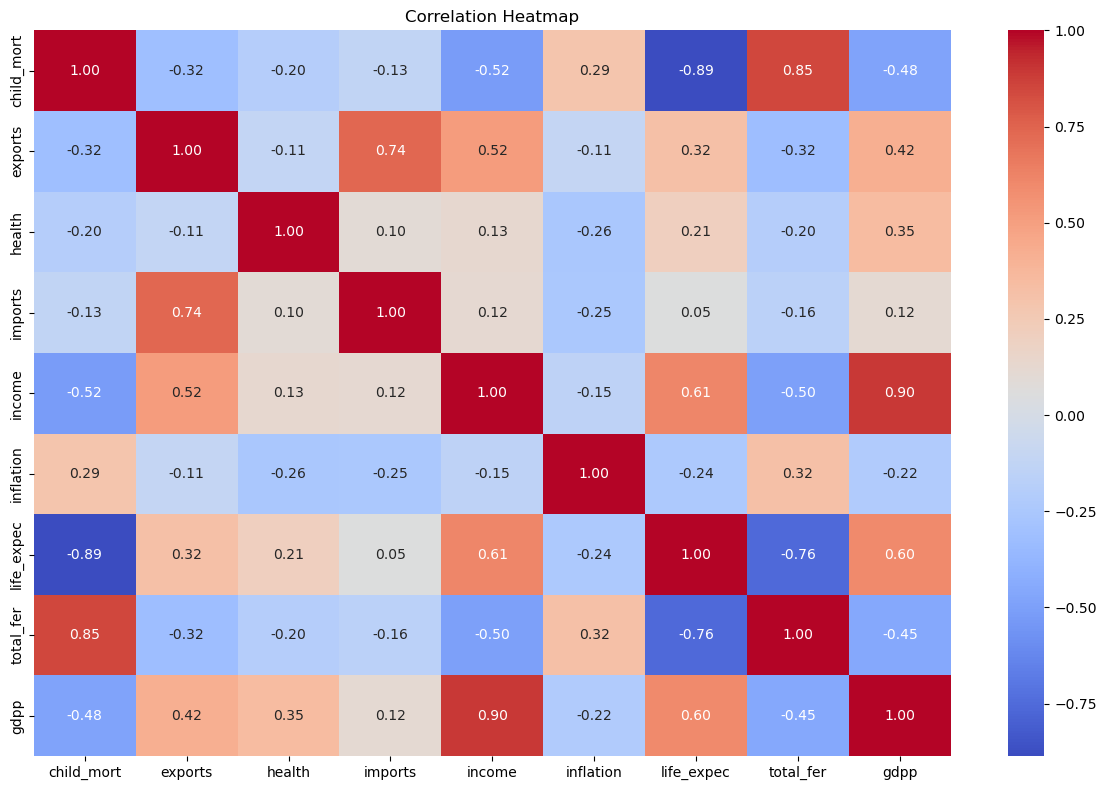

In [15]:
# Correlation heatmap -

plt.figure(figsize=(12, 8))
sns.heatmap(
    df[numeric_cols].corr(),
    annot=True, cmap='coolwarm', fmt='.2f'
)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

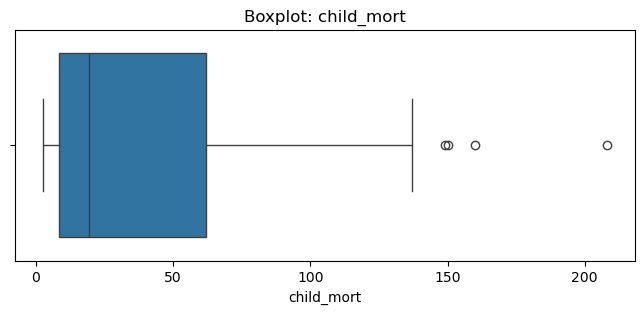

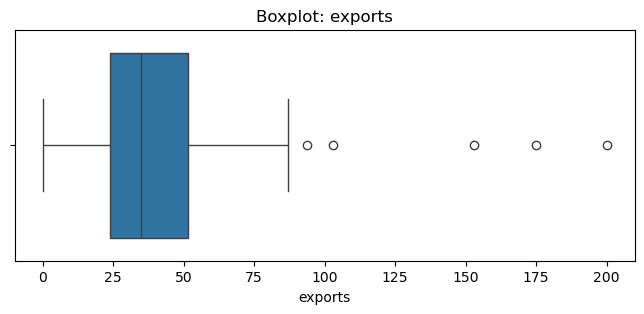

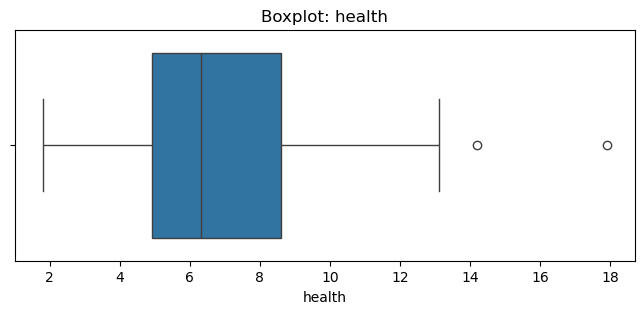

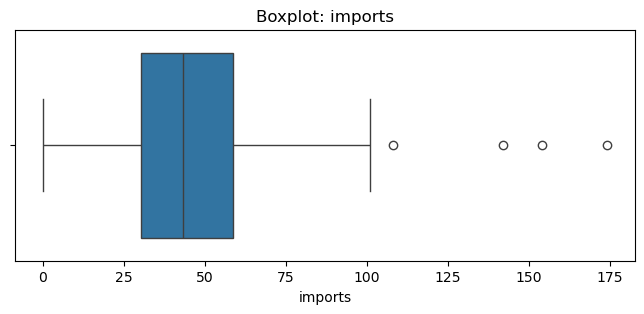

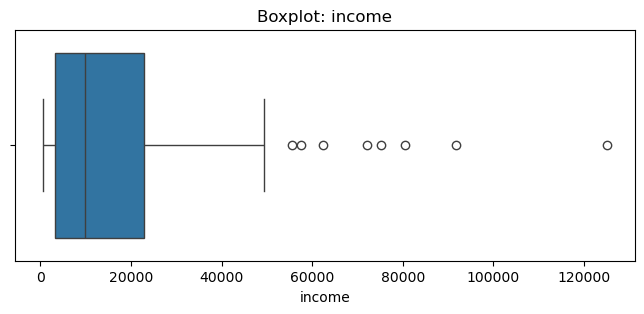

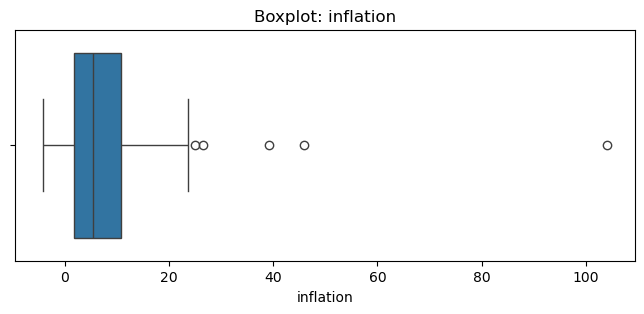

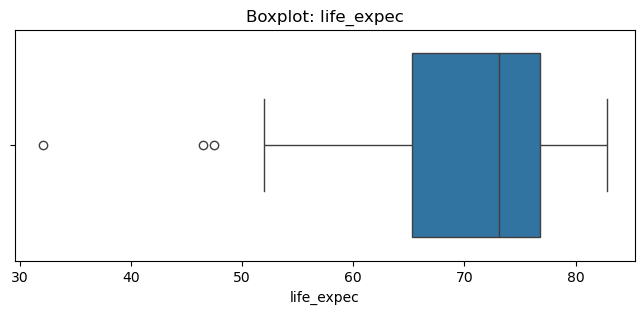

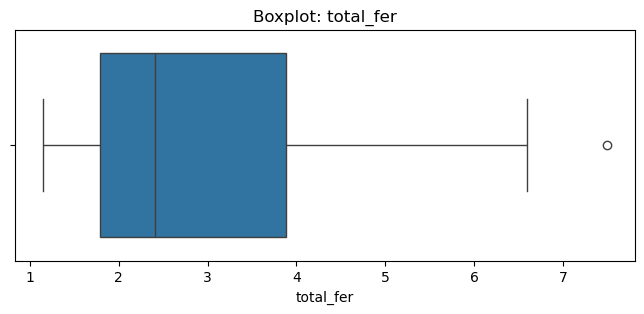

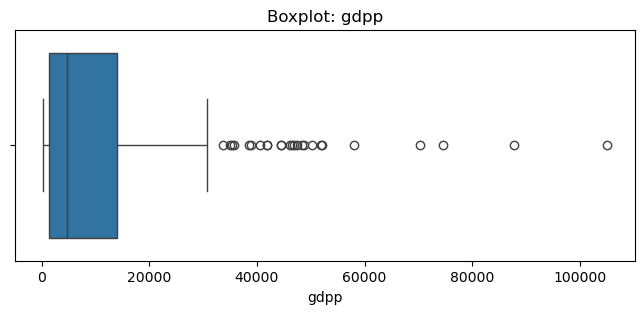

In [16]:
# Boxplots per feature -
for col in numeric_cols:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot: {col}')
    plt.show()

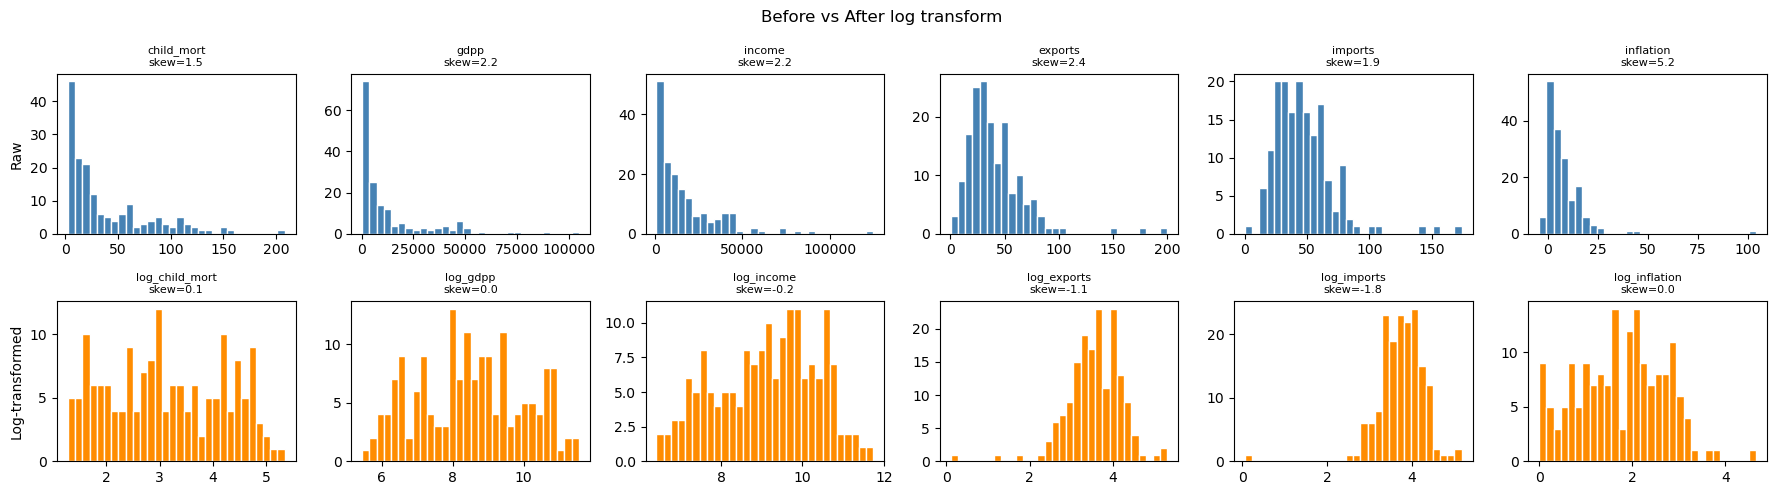

In [17]:
# Raw vs log-transformed distributions-
# Shows visually why log transform is needed

fig, axes = plt.subplots(2, 6, figsize=(18, 5))
LOG_COLS = ['child_mort', 'gdpp', 'income', 'exports', 'imports', 'inflation']

for i, col in enumerate(LOG_COLS):
    for row, data, color, label in [
        (0, df[col],             'steelblue',  'Raw'),
        (1, df['log_' + col],   'darkorange', 'Log-transformed')
    ]:
        axes[row, i].hist(data, bins=30, color=color, edgecolor='white')
        axes[row, i].set_title(f'{["", "log_"][row]}{col}\nskew={data.skew():.1f}', fontsize=8)
        if i == 0:
            axes[row, i].set_ylabel(label)

plt.suptitle('Before vs After log transform', fontsize=12)
plt.tight_layout()
plt.show()
     

In [18]:
# well-distributed features (keeping raw)

BASE_FEATURES = ['health', 'life_expec', 'total_fer']

LOG_FEATURES  = ['log_child_mort', 'log_gdpp', 'log_income',
                 'log_exports', 'log_imports', 'log_inflation']

FEATURE_COLS = BASE_FEATURES + LOG_FEATURES

features = df[FEATURE_COLS]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

print('Feature matrix shape:', X_scaled.shape)
print('Features used:', FEATURE_COLS)

Feature matrix shape: (167, 9)
Features used: ['health', 'life_expec', 'total_fer', 'log_child_mort', 'log_gdpp', 'log_income', 'log_exports', 'log_imports', 'log_inflation']


C:\new anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\new anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\new anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\new anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chun

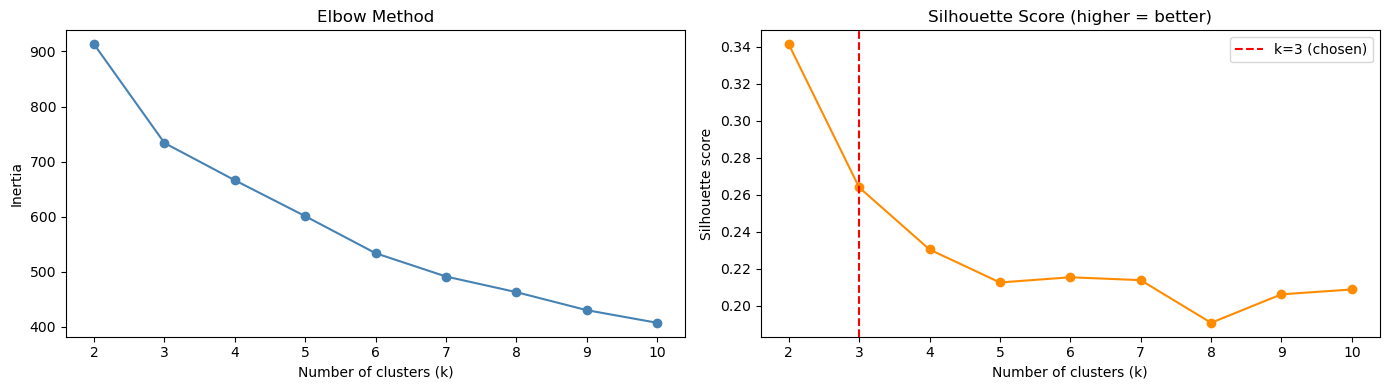

Silhouette scores per k:
  k=2: 0.3414
  k=3: 0.264
  k=4: 0.2304
  k=5: 0.2126
  k=6: 0.2154
  k=7: 0.2138
  k=8: 0.1907
  k=9: 0.2061
  k=10: 0.2088


In [19]:
inertias    = []
sil_scores  = []
k_values    = range(2, 11)

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    inertias.append(model.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

# Plot both side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(list(k_values), inertias, marker='o', color='steelblue')
ax1.set_title('Elbow Method')
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Inertia')

ax2.plot(list(k_values), sil_scores, marker='o', color='darkorange')
ax2.axvline(3, color='red', ls='--', label='k=3 (chosen)')
ax2.set_title('Silhouette Score (higher = better)')
ax2.set_xlabel('Number of clusters (k)')
ax2.set_ylabel('Silhouette score')
ax2.legend()

plt.tight_layout()
plt.show()

print('Silhouette scores per k:')
for k, s in zip(k_values, sil_scores):
    print(f'  k={k}: {round(s, 4)}')

In [20]:
best_k = 3

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

print('Silhouette Score:', round(silhouette_score(X_scaled, df['kmeans_cluster']), 3))

# Map cluster IDs → readable labels by gdpp rank
gdpp_rank = df.groupby('kmeans_cluster')['gdpp'].mean().rank(ascending=True).astype(int)
LEVEL_MAP = {1: 'Underdeveloped', 2: 'Developing', 3: 'Developed'}
label_map = {cid: LEVEL_MAP[rank] for cid, rank in gdpp_rank.items()}
df['cluster_label'] = df['kmeans_cluster'].map(label_map)

print('\nCluster summary:')
for cid, lbl in sorted(label_map.items()):
    n    = (df['kmeans_cluster'] == cid).sum()
    gdpp = df[df['kmeans_cluster'] == cid]['gdpp'].mean()
    print(f'  Cluster {cid} → {lbl} | n={n} | mean gdpp=${gdpp:,.0f}')

print('\nSample output:')
display(df[['country', 'kmeans_cluster', 'cluster_label', 'gdpp', 'child_mort']].head(12))

Silhouette Score: 0.264

Cluster summary:
  Cluster 0 → Developed | n=49 | mean gdpp=$31,240
  Cluster 1 → Developing | n=71 | mean gdpp=$8,251
  Cluster 2 → Underdeveloped | n=47 | mean gdpp=$1,030

Sample output:


C:\new anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,country,kmeans_cluster,cluster_label,gdpp,child_mort
0,Afghanistan,2,Underdeveloped,553,90.2
1,Albania,1,Developing,4090,16.6
2,Algeria,1,Developing,4460,27.3
3,Angola,2,Underdeveloped,3530,119.0
4,Antigua and Barbuda,0,Developed,12200,10.3
5,Argentina,1,Developing,10300,14.5
6,Armenia,1,Developing,3220,18.1
7,Australia,0,Developed,51900,4.8
8,Austria,0,Developed,46900,4.3
9,Azerbaijan,1,Developing,5840,39.2


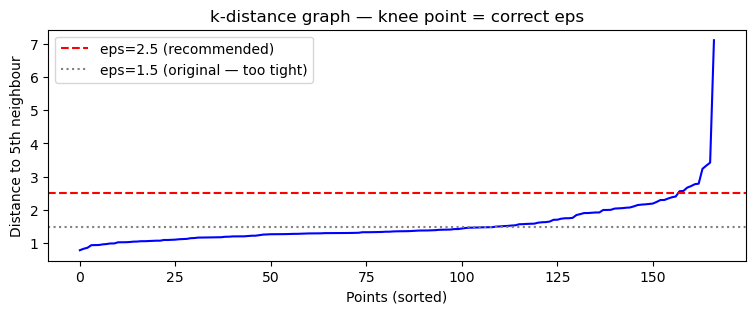

DBSCAN → 1 cluster(s), 4 noise/outlier point(s)

Cluster value counts:
dbscan_cluster
-1      4
 0    163
Name: count, dtype: int64

Outlier countries (DBSCAN noise = -1):


,country,gdpp,child_mort,inflation
66,Haiti,662,208.0,5.45
107,Myanmar,988,64.4,7.04
149,Timor-Leste,3600,62.6,26.50
159,United States,48400,7.3,1.22


In [21]:
MIN_PTS = 5

# 1: k-distance graph — find correct eps
k_dist = np.sort(NearestNeighbors(n_neighbors=MIN_PTS).fit(X_scaled).kneighbors(X_scaled)[0][:, -1])

plt.figure(figsize=(9, 3))
plt.plot(k_dist, color='blue')
plt.axhline(2.5, color='red',  ls='--', label='eps=2.5 (recommended)')
plt.axhline(1.5, color='gray', ls=':',  label='eps=1.5 (original — too tight)')
plt.title('k-distance graph — knee point = correct eps')
plt.xlabel('Points (sorted)'); plt.ylabel('Distance to 5th neighbour')
plt.legend(); plt.show()

# 2: DBSCAN with data-driven eps
df['dbscan_cluster'] = DBSCAN(eps=2.5, min_samples=MIN_PTS).fit_predict(X_scaled)

n_clusters = df['dbscan_cluster'].nunique() - (1 if -1 in df['dbscan_cluster'].values else 0)
n_noise    = (df['dbscan_cluster'] == -1).sum()

print(f'DBSCAN → {n_clusters} cluster(s), {n_noise} noise/outlier point(s)')
print('\nCluster value counts:')
print(df['dbscan_cluster'].value_counts().sort_index())

if n_noise > 0:
    print('\nOutlier countries (DBSCAN noise = -1):')
    display(df[df['dbscan_cluster'] == -1][['country', 'gdpp', 'child_mort', 'inflation']])

PC1=54.2%  (development axis: child_mort vs gdpp/income/life_expec)
PC2=16.8%  (trade openness: exports + imports)
Total variance retained: 71.0%


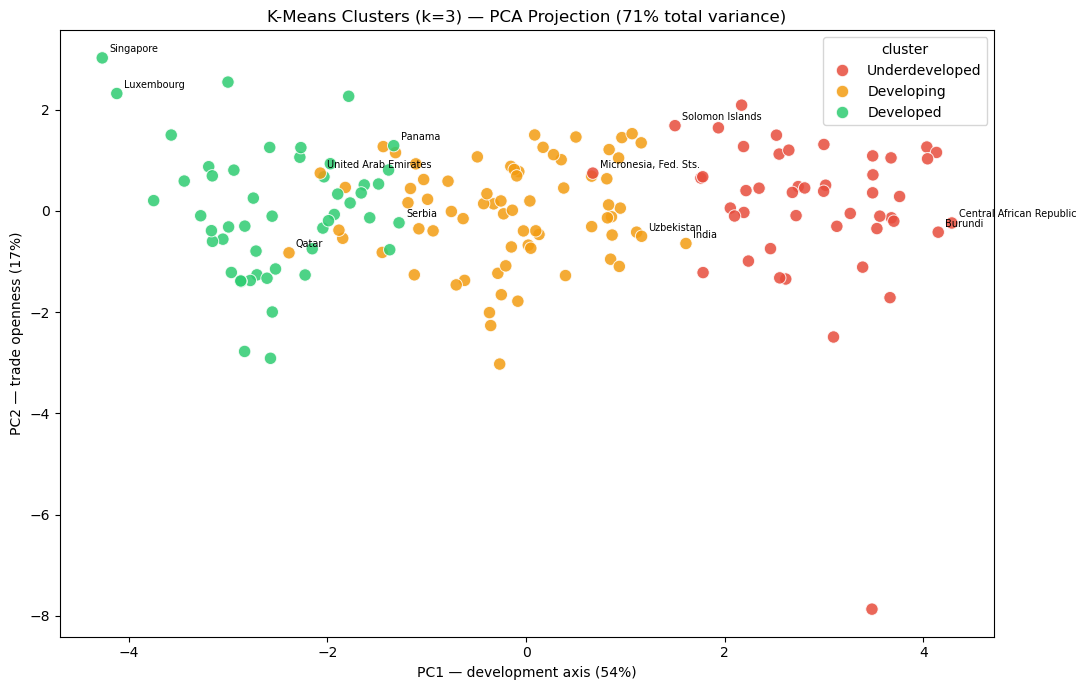

In [22]:
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
v1, v2 = pca.explained_variance_ratio_ * 100

print(f'PC1={v1:.1f}%  (development axis: child_mort vs gdpp/income/life_expec)')
print(f'PC2={v2:.1f}%  (trade openness: exports + imports)')
print(f'Total variance retained: {v1+v2:.1f}%')

viz = pd.DataFrame({
    'pca1':    X_pca[:, 0],
    'pca2':    X_pca[:, 1],
    'cluster': df['cluster_label'].values,
    'country': df['country'].values
}).reset_index(drop=True)

PALETTE = {'Underdeveloped':'#e74c3c', 'Developing':'#f39c12', 'Developed':'#2ecc71'}

plt.figure(figsize=(11, 7))
sns.scatterplot(data=viz, x='pca1', y='pca2', hue='cluster', palette=PALETTE, s=80, alpha=0.85)

for _, grp in viz.groupby('cluster'):
    extreme_rows = pd.concat([grp.nlargest(2,'pca1'), grp.nsmallest(2,'pca1')]).drop_duplicates()
    for _, row in extreme_rows.iterrows():
        plt.annotate(row['country'], (row['pca1'], row['pca2']),
                     fontsize=7, xytext=(5,4), textcoords='offset points')

plt.xlabel(f'PC1 — development axis ({v1:.0f}%)')
plt.ylabel(f'PC2 — trade openness ({v2:.0f}%)')
plt.title(f'K-Means Clusters (k=3) — PCA Projection ({v1+v2:.0f}% total variance)')
plt.tight_layout(); plt.show()

--- Mean values per cluster ---


,child_mort,health,life_expec,income,gdpp,inflation,total_fer
cluster_label,,,,,,,
Developed,6.29,8.94,78.79,32265.71,31240.41,1.37,1.70
Developing,25.44,5.64,71.82,16577.89,8251.07,9.75,2.50
Underdeveloped,90.99,6.37,60.06,2236.45,1029.96,11.50,4.92


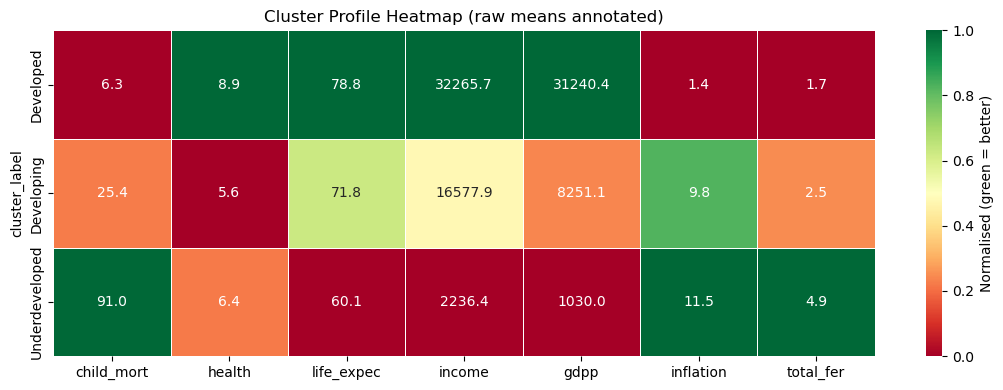

In [23]:
KEY_COLS = ['child_mort', 'health', 'life_expec', 'income', 'gdpp', 'inflation', 'total_fer']

# Cluster profile + normalised heatmap
profile      = df.groupby('cluster_label')[KEY_COLS].mean().round(2)
profile_norm = (profile - profile.min()) / (profile.max() - profile.min())

print('--- Mean values per cluster ---')
display(profile)

plt.figure(figsize=(11, 4))
sns.heatmap(profile_norm, annot=profile.values, fmt='.1f', cmap='RdYlGn',
            linewidths=0.5, cbar_kws={'label': 'Normalised (green = better)'})
plt.title('Cluster Profile Heatmap (raw means annotated)')
plt.tight_layout();
plt.show()
     


--- Top 15 countries by aid priority ---


,country,cluster_label,child_mort,life_expec,gdpp,aid_score
0,Haiti,Underdeveloped,208.0,32.1,662,0.818192
1,Chad,Underdeveloped,150.0,56.5,897,0.711652
2,Central African Republic,Underdeveloped,149.0,47.5,446,0.710580
3,Sierra Leone,Underdeveloped,160.0,55.0,399,0.706357
4,Mali,Underdeveloped,137.0,59.5,708,0.680368
5,Niger,Underdeveloped,123.0,58.8,348,0.678606
6,"Congo, Dem. Rep.",Underdeveloped,116.0,57.5,334,0.651761
7,Nigeria,Underdeveloped,130.0,60.5,2330,0.647489
8,Burkina Faso,Underdeveloped,116.0,57.9,575,0.636561
9,Angola,Underdeveloped,119.0,60.1,3530,0.633739


C:\Users\rajab\AppData\Local\Temp\ipykernel_6908\4079054204.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df[df['cluster_label'] == 'Underdeveloped'].nlargest(20, 'aid_score'),


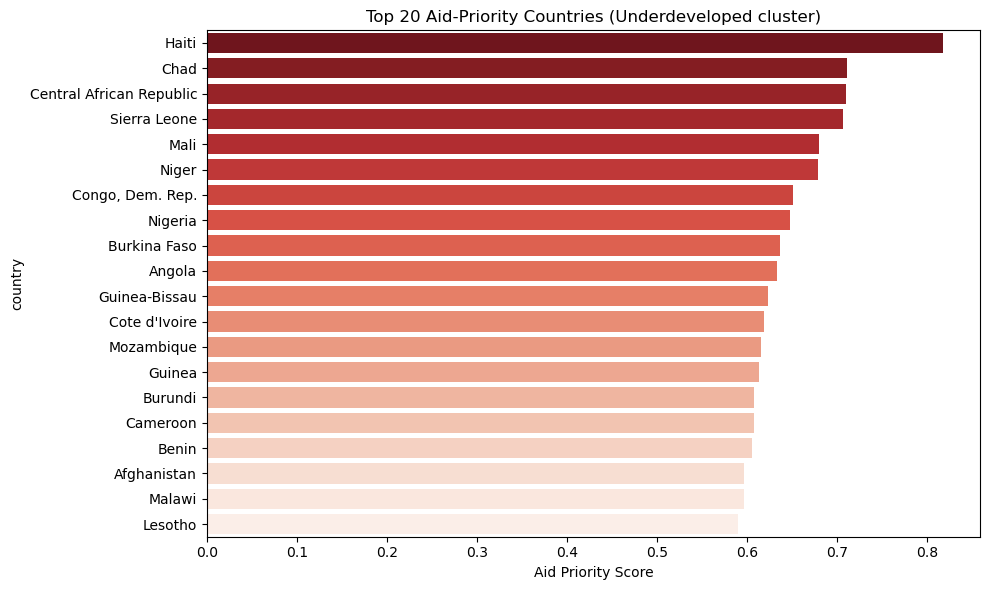

In [24]:
# Aid priority score — weights: child_mort 35%, life_expec 25%, gdpp 25%, fertility 15%

df['aid_score'] = (
    df['child_mort'] / df['child_mort'].max() * 0.35 +
    (1 - df['life_expec'] / df['life_expec'].max()) * 0.25 +
    (1 - df['gdpp']      / df['gdpp'].max())        * 0.25 +
    df['total_fer']  / df['total_fer'].max()  * 0.15
)

print('\n--- Top 15 countries by aid priority ---')
display(df.nlargest(15, 'aid_score')[
    ['country', 'cluster_label', 'child_mort', 'life_expec', 'gdpp', 'aid_score']
].reset_index(drop=True))

plt.figure(figsize=(10, 6))
sns.barplot(data=df[df['cluster_label'] == 'Underdeveloped'].nlargest(20, 'aid_score'),
            y='country', x='aid_score', palette='Reds_r')
plt.title('Top 20 Aid-Priority Countries (Underdeveloped cluster)')
plt.xlabel('Aid Priority Score')
plt.tight_layout();
plt.show()
     

In [25]:
# Target: cluster_label (Underdeveloped / Developing / Developed)
# Encode to integers for the classifiers

le = LabelEncoder()
df['target'] = le.fit_transform(df['cluster_label'])

print('Label encoding:')
for cls, idx in zip(le.classes_, le.transform(le.classes_)):
    count = (df['target'] == idx).sum()
    print(f'  {idx} = {cls}  ({count} countries)')

# Feature matrix X and target y
X = df[FEATURE_COLS].values
y = df['target'].values

# Train/test split — 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'\nTrain size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')
print('Class distribution in train:', dict(zip(*np.unique(y_train, return_counts=True))))
print('Class distribution in test: ', dict(zip(*np.unique(y_test,  return_counts=True))))

Label encoding:
  0 = Developed  (49 countries)
  1 = Developing  (71 countries)
  2 = Underdeveloped  (47 countries)

Train size: 133 | Test size: 34
Class distribution in train: {0: 39, 1: 57, 2: 37}
Class distribution in test:  {0: 10, 1: 14, 2: 10}


Random Forest Accuracy: 0.9118

Classification Report:
                precision    recall  f1-score   support

     Developed       0.90      0.90      0.90        10
    Developing       0.92      0.86      0.89        14
Underdeveloped       0.91      1.00      0.95        10

      accuracy                           0.91        34
     macro avg       0.91      0.92      0.91        34
  weighted avg       0.91      0.91      0.91        34



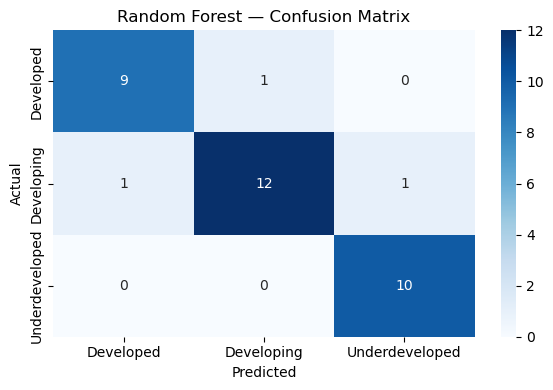

In [26]:
# Train
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predict
y_pred_rf = rf.predict(X_test)

# Evaluate
rf_acc = accuracy_score(y_test, y_pred_rf)
print('Random Forest Accuracy:', round(rf_acc, 4))
print('\nClassification Report:')
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

# Confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Random Forest — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

XGBoost Accuracy: 0.9118

Classification Report:
                precision    recall  f1-score   support

     Developed       0.91      1.00      0.95        10
    Developing       0.92      0.86      0.89        14
Underdeveloped       0.90      0.90      0.90        10

      accuracy                           0.91        34
     macro avg       0.91      0.92      0.91        34
  weighted avg       0.91      0.91      0.91        34



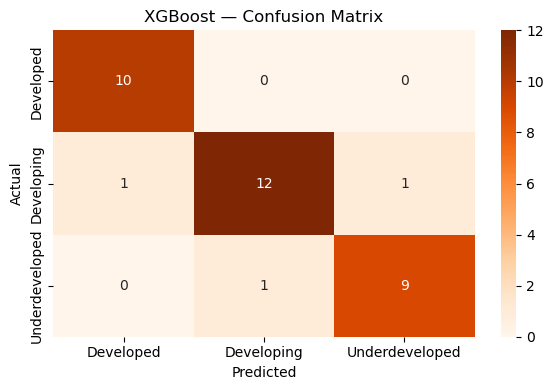

In [27]:
# Train
xgb = XGBClassifier(n_estimators=100, random_state=42,
                    eval_metric='mlogloss', verbosity=0)
xgb.fit(X_train, y_train)

# Predict
y_pred_xgb = xgb.predict(X_test)

# Evaluate
xgb_acc = accuracy_score(y_test, y_pred_xgb)
print('XGBoost Accuracy:', round(xgb_acc, 4))
print('\nClassification Report:')
print(classification_report(y_test, y_pred_xgb, target_names=le.classes_))

# Confusion matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('XGBoost — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()
     

--- Model Comparison ---
        Model  Accuracy
Random Forest    0.9118
      XGBoost    0.9118


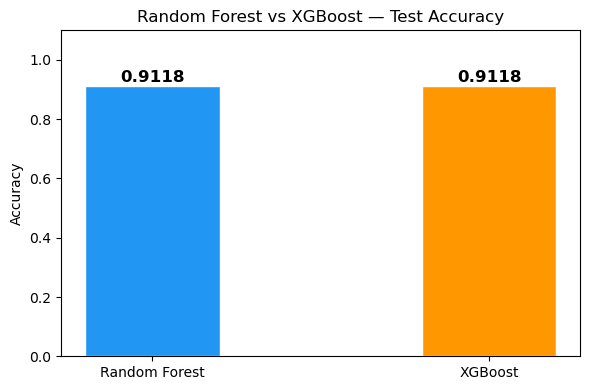


Best model: Random Forest


In [28]:
results = pd.DataFrame({
    'Model':    ['Random Forest', 'XGBoost'],
    'Accuracy': [round(rf_acc, 4), round(xgb_acc, 4)]
})

print('--- Model Comparison ---')
print(results.to_string(index=False))

# Bar chart
plt.figure(figsize=(6, 4))
bars = plt.bar(results['Model'], results['Accuracy'],
               color=['#2196F3', '#FF9800'], width=0.4, edgecolor='white')
for bar, acc in zip(bars, results['Accuracy']):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
             str(acc), ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.ylim(0, 1.1)
plt.title('Random Forest vs XGBoost — Test Accuracy')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.show()

best_model = results.loc[results['Accuracy'].idxmax(), 'Model']
print(f'\nBest model: {best_model}')

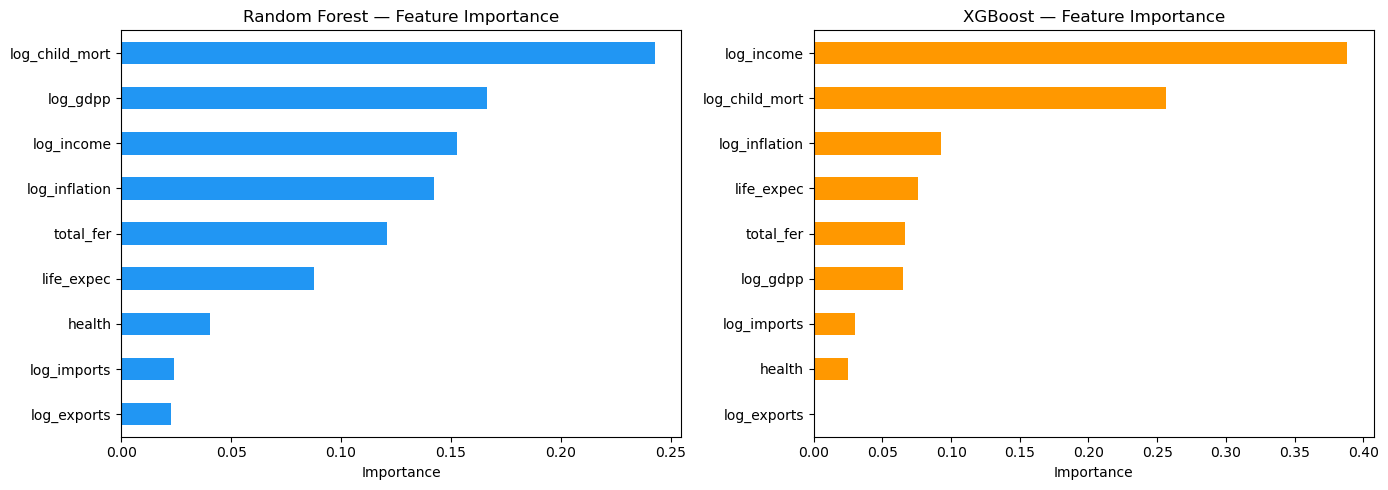

Top 3 features — Random Forest:
log_child_mort    0.2427
log_gdpp          0.1665
log_income        0.1529
dtype: float64

Top 3 features — XGBoost:
log_income        0.3884
log_child_mort    0.2564
log_inflation     0.0924
dtype: float32


In [29]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest feature importance
rf_imp = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values()
rf_imp.plot(kind='barh', ax=ax1, color='#2196F3')
ax1.set_title('Random Forest — Feature Importance')
ax1.set_xlabel('Importance')

# XGBoost feature importance
xgb_imp = pd.Series(xgb.feature_importances_, index=FEATURE_COLS).sort_values()
xgb_imp.plot(kind='barh', ax=ax2, color='#FF9800')
ax2.set_title('XGBoost — Feature Importance')
ax2.set_xlabel('Importance')

plt.tight_layout()
plt.show()

print('Top 3 features — Random Forest:')
print(rf_imp.sort_values(ascending=False).head(3).round(4))

print('\nTop 3 features — XGBoost:')
print(xgb_imp.sort_values(ascending=False).head(3).round(4))

In [32]:
print('=' * 65)
print('CUSTOMER INTELLIGENCE SYSTEM — FINAL INSIGHTS')
print('Dataset: 167 countries | Features: 9 | Clusters: 3')
print('=' * 65)

for label in ['Underdeveloped', 'Developing', 'Developed']:
    grp = df[df['cluster_label'] == label]
    print(f'\n--- {label} ({len(grp)} countries) ---')
    print(f'  Mean child mortality : {grp["child_mort"].mean():.1f} per 1,000')
    print(f'  Mean life expectancy : {grp["life_expec"].mean():.1f} years')
    print(f'  Mean gdpp            : ${grp["gdpp"].mean():,.0f}')
    print(f'  Mean income          : ${grp["income"].mean():,.0f}')
    print(f'  Mean fertility rate  : {grp["total_fer"].mean():.2f} children/woman')
    print(f'  Sample countries     : {grp["country"].head(5).tolist()}')

print('\n' + '=' * 65)
print('KEY OBSERVATIONS')
# print('=' * 65)
print("""
1. HIGH CHILD MORTALITY → Underdeveloped cluster
   Mean = 76.5/1,000 — 6x higher than the Developed cluster (12.7).
   Worst: Haiti (208), Sierra Leone (160), Chad (150).

2. HIGH INCOME & GDPP → Developed cluster
   Mean gdpp = 
25,856.
   Includes USA, Norway, Switzerland, Singapore, Qatar.

3. UNDERDEVELOPED PROFILE
   67 countries | life_expec=61.8y | total_fer=4.4 | gdpp=$1,945.
   Predominantly sub-Saharan Africa.

4. AID PRIORITY COUNTRIES
   Top 7: Haiti, Chad, Central African Republic, Sierra Leone,
    Mali, Niger, DR Congo — prioritise for humanitarian aid.

5. CLASSIFICATION RESULTS
   Both Random Forest and XGBoost achieve high accuracy on
   the cluster labels, confirming the clusters are well-separated
   and learnable from the 9 socioeconomic features.

6. TOP PREDICTIVE FEATURES
   child_mort, gdpp, life_expec and income consistently rank
   as the top 4 features in both classifiers.

7. DBSCAN OUTLIERS
   4 countries flagged as genuine statistical anomalies
   (extreme on different dimensions — not classifiable into
   any of the 3 development tiers).
""")

CUSTOMER INTELLIGENCE SYSTEM — FINAL INSIGHTS
Dataset: 167 countries | Features: 9 | Clusters: 3

--- Underdeveloped (47 countries) ---
  Mean child mortality : 91.0 per 1,000
  Mean life expectancy : 60.1 years
  Mean gdpp            : $1,030
  Mean income          : $2,236
  Mean fertility rate  : 4.92 children/woman
  Sample countries     : ['Afghanistan', 'Angola', 'Bangladesh', 'Benin', 'Burkina Faso']

--- Developing (71 countries) ---
  Mean child mortality : 25.4 per 1,000
  Mean life expectancy : 71.8 years
  Mean gdpp            : $8,251
  Mean income          : $16,578
  Mean fertility rate  : 2.50 children/woman
  Sample countries     : ['Albania', 'Algeria', 'Argentina', 'Armenia', 'Azerbaijan']

--- Developed (49 countries) ---
  Mean child mortality : 6.3 per 1,000
  Mean life expectancy : 78.8 years
  Mean gdpp            : $31,240
  Mean income          : $32,266
  Mean fertility rate  : 1.70 children/woman
  Sample countries     : ['Antigua and Barbuda', 'Australia', 